# back prop from scratch

In [1]:
import numpy as np

# Sigmoid activation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Initialize weights
np.random.seed(42)
W1 = np.random.rand(2, 2)   # input → hidden
b1 = np.zeros((1, 2))
W2 = np.random.rand(2, 1)   # hidden → output
b2 = np.zeros((1, 1))

lr = 0.5
epochs = 10000

# Training
for _ in range(epochs):
    # Forward pass
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    output_input = np.dot(hidden_output, W2) + b2
    y_pred = sigmoid(output_input)

    # Backpropagation
    error = y - y_pred
    d_output = error * sigmoid_derivative(y_pred)

    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

    # Update weights
    W2 += hidden_output.T.dot(d_output) * lr
    b2 += np.sum(d_output, axis=0, keepdims=True) * lr
    W1 += X.T.dot(d_hidden) * lr
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

# Test
print("Predictions:")
print(np.round(y_pred))


Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


In [3]:
import numpy as np
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_d(x): return x * (1 - x)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]]) # XOR
np.random.seed(0)
W1 = np.random.rand(2, 4)
W2 = np.random.rand(4, 1)
for _ in range(10000):
    h = sigmoid(X @ W1)
    out = sigmoid(h @ W2)
    err = y - out
    d2 = err * sigmoid_d(out)
    d1 = (d2 @ W2.T) * sigmoid_d(h)
    W2 += h.T @ d2 * 0.5
    W1 += X.T @ d1 * 0.5
print("Predictions:")
print(np.round(out, 2))

Predictions:
[[0.04]
 [0.97]
 [0.97]
 [0.02]]


# Back Propagation with tensorflow (8 hidden layers)

/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


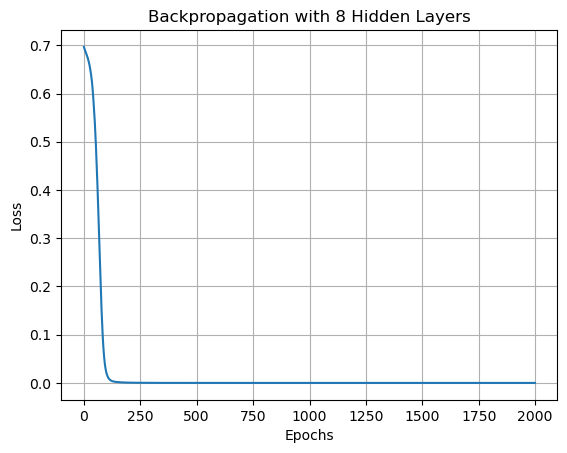

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

# Deep Neural Network (8 hidden layers)
model = Sequential()

model.add(Dense(16, input_dim=2, activation='relu'))

for _ in range(7):  # 7 more hidden layers → total 8
    model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))  # Output layer
model.compile(
    optimizer='adam',          # best for deep networks
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X, y,
    epochs=2000,
    verbose=0
)
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Backpropagation with 8 Hidden Layers")
plt.grid(True)
plt.show()

# Multi layer perceptron

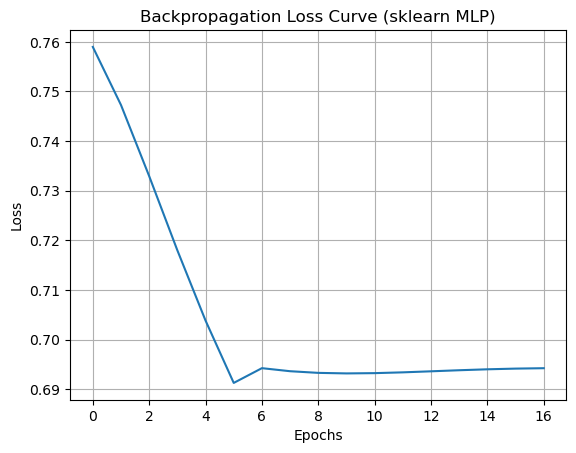

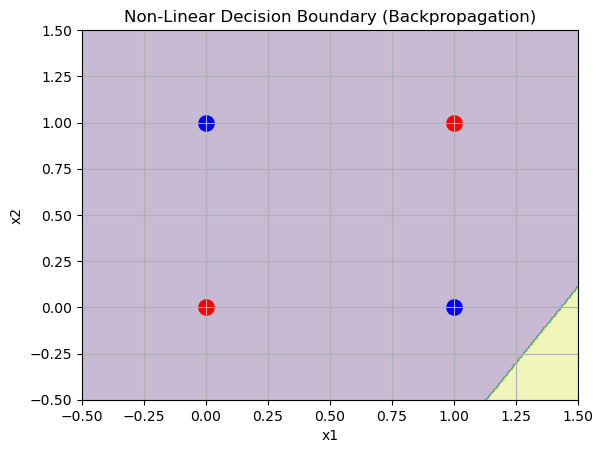

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])
model = MLPClassifier(
    hidden_layer_sizes=(2,),     # one hidden layer with 2 neurons
    activation='relu',           # non-linear activation
    solver='sgd',                # gradient descent
    learning_rate_init=0.1,
    max_iter=3000,
    random_state=42
)

model.fit(X, y)


plt.plot(model.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Backpropagation Loss Curve (sklearn MLP)")
plt.grid(True)
plt.show()
# Create grid
xx = np.linspace(-0.5, 1.5, 300)
yy = np.linspace(-0.5, 1.5, 300)
XX, YY = np.meshgrid(xx, yy)
grid = np.c_[XX.ravel(), YY.ravel()]

# Predict on grid
Z = model.predict(grid)
Z = Z.reshape(XX.shape)

# Plot decision regions
plt.contourf(XX, YY, Z, alpha=0.3)

# Plot XOR points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', s=120)
    else:
        plt.scatter(X[i][0], X[i][1], color='blue', s=120)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Non-Linear Decision Boundary (Backpropagation)")
plt.grid(True)
plt.show()


In [3]:
Z

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


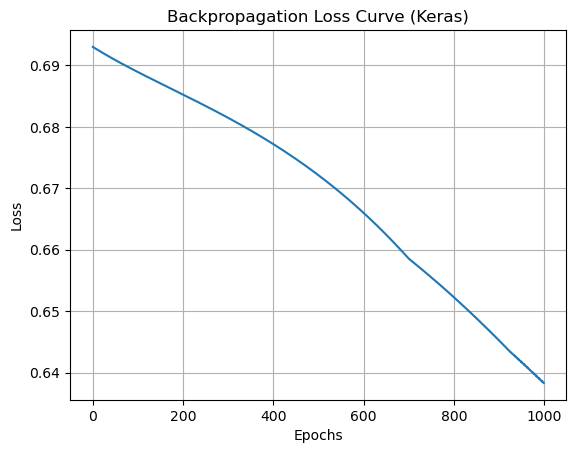

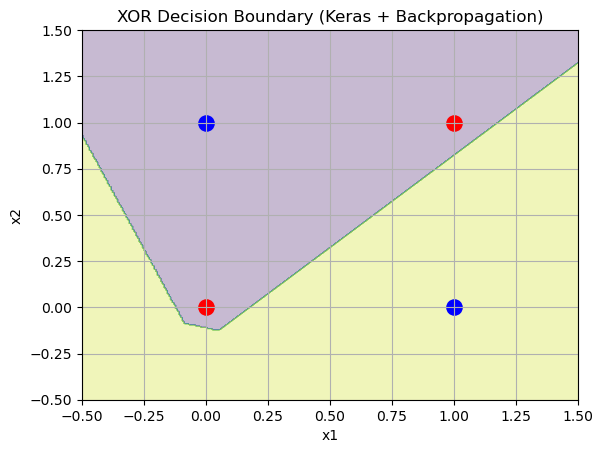

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])
model = Sequential([
    Dense(2, input_dim=2, activation='relu'),  # hidden layer
    Dense(1, activation='sigmoid')              # output layer
])
model.compile(
    optimizer='sgd',          # gradient descent
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X, y,
    epochs=1000,
    verbose=0
)
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Backpropagation Loss Curve (Keras)")
plt.grid(True)
plt.show()

# Create grid
xx = np.linspace(-0.5, 1.5, 300)
yy = np.linspace(-0.5, 1.5, 300)
XX, YY = np.meshgrid(xx, yy)
grid = np.c_[XX.ravel(), YY.ravel()]

# Predict probabilities
Z = model.predict(grid, verbose=0)
Z = (Z > 0.5).astype(int)
Z = Z.reshape(XX.shape)

# Plot decision regions
plt.contourf(XX, YY, Z, alpha=0.3)

# Plot data points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', s=120)
    else:
        plt.scatter(X[i][0], X[i][1], color='blue', s=120)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR Decision Boundary (Keras + Backpropagation)")
plt.grid(True)
plt.show()


# for iris dataset

Epoch 1/100


/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4833 - loss: 1.0166 - val_accuracy: 0.6000 - val_loss: 0.9651
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5833 - loss: 0.9903 - val_accuracy: 0.7000 - val_loss: 0.9379
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6417 - loss: 0.9644 - val_accuracy: 0.7000 - val_loss: 0.9071
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6500 - loss: 0.9369 - val_accuracy: 0.7000 - val_loss: 0.8747
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6500 - loss: 0.9064 - val_accuracy: 0.7000 - val_loss: 0.8409
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6500 - loss: 0.8751 - val_accuracy: 0.7000 - val_loss: 0.8064
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6500 - loss: 0.8418 - val_accuracy: 0.7000 - val_loss: 0.7708
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6583 - loss: 0.8084 - val_accuracy: 0.7000 - val_loss: 0.7340
Epoc

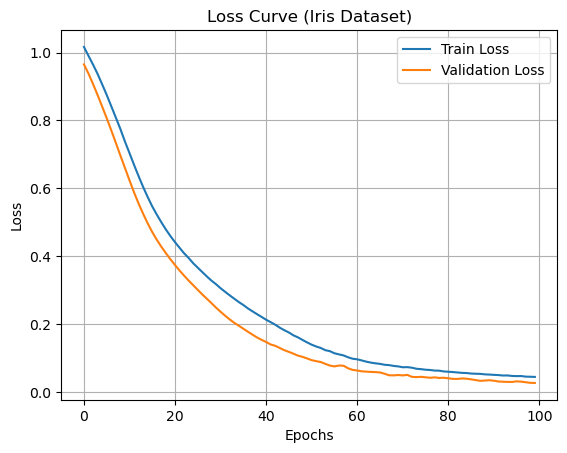

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load dataset
data = load_iris()
X = data.data
y = data.target  # 3 classes: 0,1,2

# One-hot encoding (required for multi-class classification)
y = to_categorical(y, 3)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model
model = Sequential()

model.add(Dense(16, input_dim=4, activation='relu'))

for _ in range(3):  # 3 hidden layers
    model.add(Dense(16, activation='relu'))

model.add(Dense(3, activation='softmax'))  # 3 output classes

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve (Iris Dataset)")
plt.legend()
plt.grid(True)
plt.show()